In [2]:
import os
import re
import tempfile
import nibabel as nib
import numpy as np
import torch
import torch
import torch.nn.functional as F
from torch import nn
from torch.autograd import Function
import pandas as pd
import matplotlib.pyplot as plt
from typing import Optional, Any, Mapping, Hashable
from PIL import Image
import random
from monai.utils.enums import TransformBackends
from scipy import ndimage
from monai.config.type_definitions import NdarrayOrTensor
import numpy as np
from typing import Any, Callable
import SimpleITK as sitk
from monai.config import DtypeLike, KeysCollection
from monai.data.nifti_saver import NiftiSaver
from monai.utils import convert_to_tensor
from monai.data import Dataset, DataLoader, decollate_batch, CacheDataset
random.seed(30)

from monai.transforms import (
    MapTransform,
    ConcatItemsd,
    AddChanneld,
    Compose,
    LoadImaged,
    ThresholdIntensityd,
    NormalizeIntensityd,
    ToTensord,
    Resized,
    MaskIntensityd,
    Transform,
    Spacingd,
    SpatialPadd,
    RandFlipd,
)

In [3]:
def read_split_file(path):

    with open(path, 'r') as inf:
        dict_from_file = eval(inf.read())
        
    return dict_from_file

def dataset_prep(lists, data_folder, time_steps, outcomes, endpoint):

    dataset_=[]
    outcome_file = pd.read_excel(outcomes)
    list_out = outcome_file[endpoint].values
    #outcome_file[endpoint]=torch.nn.functional.one_hot(torch.as_tensor(np.array(list(outcome_file[endpoint]))), num_classes=2).float()
    transformed_out = torch.nn.functional.one_hot(torch.as_tensor(np.array(list_out)), num_classes=2).float()

    for patient in lists:

        dict_ = {}
        
        all_names = os.listdir(os.path.join(data_folder,patient))

        dict_['ct'] = os.path.join(data_folder,patient,patient+"_ct.nii.gz")

        fractions = [int(match.group(1)) for path in all_names for match in re.finditer(r'fr_(\d+)(?=_reg)', path)]
        fractions.sort()
        selected_fr = fractions[:(time_steps+1)]
        
        if time_steps>1: #if time_step
            for j in range(time_steps):
                index_ = 'ct_'+str(j+1)
                dict_[str(index_)] = os.path.join(data_folder,patient,patient+"_ct_fr_"+str(selected_fr[j])+"_reg.nii.gz")

        dict_['mask'] = os.path.join(data_folder,patient,patient+"_ct_GTVtot.nii.gz")
        dict_['ID'] = patient

        index = list(outcome_file["PatientID"]).index(patient)
        dict_['label'] = transformed_out[index]
        
        dataset_.append(dict_)

    return dataset_

class Resized_mine(MapTransform):
    
    def __init__(self, keys, spatial_size):
        
        super().__init__(keys)
        self.spatial_size = spatial_size
        
    def resize(self, img):
        
        if np.shape(img)!=self.spatial_size:
            return img[:self.spatial_size[0],:self.spatial_size[1],:self.spatial_size[2]] #self.resizer(img) 
        else:
            return img
             

    def __call__(self, dictionary):
        
        dictionary = dict(dictionary)
        
        for key in self.keys:
            dictionary[key] = self.resize(dictionary[key]) 
        
        return dictionary
    


In [4]:
import torch
import torch.nn.functional as F
from typing import Union
from scipy.ndimage import binary_dilation
from skimage.morphology import  ball

class Dilation(MapTransform):
    
    def __init__(self, keys: str, kernel_size: Union[int, tuple]):
        self.keys = keys
        self.kernel_size = (kernel_size,) if isinstance(kernel_size, int) else kernel_size

    def __call__(self, data):
        
        for key in self.keys:
            data[key] = self.dilate(data[key], self.kernel_size)
        return data

    def dilate(self, mask, kernel_size):
        
        #structure = np.ones_like(mask)
        mask = binary_dilation(mask, ball(3))
        
        return mask

In [5]:
def initialize_transform_masked(images_keys, model_type, level, window, image_size, ct_norm="z_norm", test=False):
    
    normalize_ct={
        "z_norm": NormalizeIntensityd(keys=images_keys, subtrahend=None, divisor=None, nonzero=False, channel_wise=False, allow_missing_keys=False),
        "min_max_norm": NormalizeIntensityd(keys=images_keys, subtrahend=None, divisor=None, nonzero=False, channel_wise=False, allow_missing_keys=False)
    }
     
    max_ = 200 #level + window/2
    min_ = -200 #level - window/2
    
    mask_included = ("mask",) + images_keys
    
    if model_type=="ConvLSTM_class":
        sequence_prep=[
            LoadImaged(keys=mask_included),
            Resized_mine(keys=mask_included, spatial_size=(image_size,image_size,image_size)),
            ThresholdIntensityd(keys=images_keys, threshold=min_, above=True, cval=min_, allow_missing_keys=False),
            ThresholdIntensityd(keys=images_keys, threshold=max_, above=False, cval=max_, allow_missing_keys=False),
            normalize_ct[ct_norm],
            Dilation(keys=["mask"], kernel_size=3),
            MaskIntensityd(keys=images_keys, mask_key = "mask", select_fn=lambda x: x>0), #CropForegroundd
            AddChanneld(keys=images_keys), 
            AddChanneld(keys=images_keys),
            ConcatItemsd(keys=images_keys, name="input"),
            ToTensord(keys=["input"])
        ]

    else:
        sequence_prep=[
            LoadImaged(keys=images_keys),
            Resized_mine(keys=images_keys, spatial_size=(image_size,image_size,image_size)),
            ThresholdIntensityd(keys=images_keys, threshold=min_, above=True, cval=min_, allow_missing_keys=False),
            ThresholdIntensityd(keys=images_keys, threshold=max_, above=False, cval=max_, allow_missing_keys=False),
            normalize_ct[ct_norm],
            Dilation(keys="mask", kernel="elliptical", kernel_size=3),
            MaskIntensityd(keys=images_keys, mask_key = "mask", select_fn=lambda x: x>0),
            AddChanneld(keys=images_keys), 
            ConcatItemsd(keys=images_keys, name="input"),
            ToTensord(keys=["input"])
        ]
    
    train_tranforms = Compose(sequence_prep)
    
    return train_tranforms


In [8]:
def initialize_transform(images_keys, model_type, level, window, image_size, ct_norm="z_norm", test=False):
    
    normalize_ct={
        "z_norm": NormalizeIntensityd(keys=images_keys, subtrahend=None, divisor=None, nonzero=False, channel_wise=False, allow_missing_keys=False),
        "min_max_norm": NormalizeIntensityd(keys=images_keys, subtrahend=None, divisor=None, nonzero=False, channel_wise=False, allow_missing_keys=False)
    }
     
    max_ = 200 #level + window/2
    min_ = -200 #level - window/2
    
    if model_type=="DenseNet121" or model_type=="ResNet18" or model_type=="SEResNet50":
        sequence_prep=[
            LoadImaged(keys=images_keys),
            Spacingd(keys=images_keys, pixdim=[1.0,1.0,1.0,1.0], mode='bilinear'),
            Resized_mine(keys=images_keys, spatial_size=(image_size,image_size,image_size)),
            ThresholdIntensityd(keys=images_keys, threshold=min_, above=True, cval=min_, allow_missing_keys=False),
            ThresholdIntensityd(keys=images_keys, threshold=max_, above=False, cval=max_, allow_missing_keys=False),
            normalize_ct[ct_norm],
            AddChanneld(keys=images_keys), 
            ConcatItemsd(keys=images_keys, name="input"),
            ToTensord(keys=["input"])
        ]
    else:
        sequence_prep=[
            LoadImaged(keys=images_keys),
            Resized_mine(keys=images_keys, spatial_size=(image_size,image_size,image_size)),
            ThresholdIntensityd(keys=images_keys, threshold=min_, above=True, cval=min_, allow_missing_keys=False),
            ThresholdIntensityd(keys=images_keys, threshold=max_, above=False, cval=max_, allow_missing_keys=False),
            normalize_ct[ct_norm],
            AddChanneld(keys=images_keys), 
            AddChanneld(keys=images_keys),
            ConcatItemsd(keys=images_keys, name="input"),
            ToTensord(keys=["input"])
        ]

    train_tranforms = Compose(sequence_prep)
    
    return train_tranforms


In [9]:
split_folder ='/scratch/p302386/experimentsLongitudinal/data_split/'

In [10]:
split_file = os.path.join(split_folder,"data_split_seqNum_2.txt")
split_data = read_split_file(split_file)

In [11]:
train_list = dataset_prep(split_data['train'],'/scratch/p302386/dataLongitudinal/', 2, '/scratch/p302386/experimentsLongitudinal/outcomes.xlsx', "DFS")[:2]

images_keys = tuple([j for j in train_list[0].keys() if "ct" in j])

train_tranforms = initialize_transform(images_keys, "ConvLSTM_class", level=60, window=350, image_size = 192, ct_norm="z_norm",test=False)

In [12]:
train_list

[{'ct': '/scratch/p302386/dataLongitudinal/UMCG-0020715/UMCG-0020715_ct.nii.gz',
  'ct_1': '/scratch/p302386/dataLongitudinal/UMCG-0020715/UMCG-0020715_ct_fr_3_reg.nii.gz',
  'ct_2': '/scratch/p302386/dataLongitudinal/UMCG-0020715/UMCG-0020715_ct_fr_8_reg.nii.gz',
  'mask': '/scratch/p302386/dataLongitudinal/UMCG-0020715/UMCG-0020715_ct_GTVtot.nii.gz',
  'ID': 'UMCG-0020715',
  'label': tensor([1., 0.])},
 {'ct': '/scratch/p302386/dataLongitudinal/UMCG-0021879/UMCG-0021879_ct.nii.gz',
  'ct_1': '/scratch/p302386/dataLongitudinal/UMCG-0021879/UMCG-0021879_ct_fr_2_reg.nii.gz',
  'ct_2': '/scratch/p302386/dataLongitudinal/UMCG-0021879/UMCG-0021879_ct_fr_7_reg.nii.gz',
  'mask': '/scratch/p302386/dataLongitudinal/UMCG-0021879/UMCG-0021879_ct_GTVtot.nii.gz',
  'ID': 'UMCG-0021879',
  'label': tensor([1., 0.])}]

In [13]:
#test = initialize_transform_masked(images_keys, "ConvLSTM_class", level=60, window=350, image_size = 192, ct_norm="z_norm",test=False)

train_ds = Dataset(data=train_list, transform=train_tranforms)

train_loader = DataLoader(train_ds, batch_size=1, shuffle=True, num_workers=1, pin_memory=False) #changed to False

In [11]:
for batch_data in train_loader:
            
    inputs, labels = batch_data["input"], batch_data["label"]

In [12]:
images_keys = ("ct")

In [14]:
transforms = Compose([
    LoadImaged(keys=["ct","mask"]),
    Spacingd(keys=["ct","mask"], pixdim=[1.0,1.0,1.0], mode='bilinear'),
])

# Apply the transform to your data
transformed_data = transforms(train_list)

# Visualize the transformed mask
ct = transformed_data[0]["ct"]#.squeeze()
np.shape(ct)

(192, 192, 96)

In [32]:
from monai.transforms import (
    MapTransform,
    ConcatItemsd,
    AddChanneld,
    Compose,
    LoadImaged,
    ThresholdIntensityd,
    NormalizeIntensityd,
    ToTensord,
    Resized,
    MaskIntensityd,
    Transform,
    Spacingd,
    Affined,
    EnsureChannelFirstD,
)

def print_pixel_spacing(data, keys):
    for item in data:
        for key in keys:
            spacing = item[f'{key}_meta_dict']['pixdim'][1:4]  # Extract pixel spacing
            print(f"{key} pixel spacing: {spacing}")

            
original_spacing = (1, 1, 2)  # (spacing along x, spacing along y, spacing along z)
target_spacing = (1, 1, 1)  # (spacing along x, spacing along y, spacing along z)

# Compute the scaling factors for isotropic resolution
scaling_factors = tuple([original / target for original, target in zip(original_spacing, target_spacing)])
print(scaling_factors)

# Define the transformation pipeline
transforms = Compose([
    LoadImaged(keys=["ct", "mask"]),
    ToTensord(keys=["input"]),
    Affined(keys=["ct", "mask"],scale_params=scaling_factors,mode=("bilinear", "nearest"))  
])

transformed_data = [transforms(item) for item in train_list]

# Print the pixel spacing of the loaded images
print_pixel_spacing(transformed_data, keys=["ct", "mask"])


(1.0, 1.0, 2.0)

=== Transform input info -- ToTensord ===

=== Transform input info -- ToTensord ===

=== Transform input info -- ToTensord ===

=== Transform input info -- ToTensord ===

=== Transform input info -- ToTensord ===

=== Transform input info -- ToTensord ===
ct statistics:
Type: <class 'numpy.ndarray'> float32
Shape: (192, 192, 96)
Value range: (-1555.3502197265625, 3546.486083984375)
ct statistics:
Type: <class 'numpy.ndarray'> float32
Shape: (192, 192, 96)
Value range: (-1555.3502197265625, 3546.486083984375)
ct statistics:
Type: <class 'numpy.ndarray'> float32
Shape: (192, 192, 96)
Value range: (-1555.3502197265625, 3546.486083984375)
ct statistics:
Type: <class 'numpy.ndarray'> float32
Shape: (192, 192, 96)
Value range: (-1555.3502197265625, 3546.486083984375)
ct statistics:
Type: <class 'numpy.ndarray'> float32
Shape: (192, 192, 96)
Value range: (-1555.3502197265625, 3546.486083984375)
ct statistics:
Type: <class 'numpy.ndarray'> float32
Shape: (192, 192, 96)
Value 

ct_meta_dict statistics:
Type: <class 'dict'> None
Value: {'sizeof_hdr': array(348, dtype=int32), 'extents': array(0, dtype=int32), 'session_error': array(0, dtype=int16), 'dim_info': array(0, dtype=uint8), 'dim': array([  3, 192, 192,  96,   1,   1,   1,   1], dtype=int16), 'intent_p1': array(0., dtype=float32), 'intent_p2': array(0., dtype=float32), 'intent_p3': array(0., dtype=float32), 'intent_code': array(0, dtype=int16), 'datatype': array(16, dtype=int16), 'bitpix': array(32, dtype=int16), 'slice_start': array(0, dtype=int16), 'pixdim': array([1., 1., 1., 2., 0., 0., 0., 0.], dtype=float32), 'vox_offset': array(0., dtype=float32), 'scl_slope': array(nan, dtype=float32), 'scl_inter': array(nan, dtype=float32), 'slice_end': array(0, dtype=int16), 'slice_code': array(0, dtype=uint8), 'xyzt_units': array(2, dtype=uint8), 'cal_max': array(0., dtype=float32), 'cal_min': array(0., dtype=float32), 'slice_duration': array(0., dtype=float32), 'toffset': array(0., dtype=float32), 'glmax': a

mask_meta_dict statistics:
Type: <class 'dict'> None
Value: {'sizeof_hdr': array(348, dtype=int32), 'extents': array(0, dtype=int32), 'session_error': array(0, dtype=int16), 'dim_info': array(0, dtype=uint8), 'dim': array([  3, 192, 192,  96,   1,   1,   1,   1], dtype=int16), 'intent_p1': array(0., dtype=float32), 'intent_p2': array(0., dtype=float32), 'intent_p3': array(0., dtype=float32), 'intent_code': array(0, dtype=int16), 'datatype': array(16, dtype=int16), 'bitpix': array(32, dtype=int16), 'slice_start': array(0, dtype=int16), 'pixdim': array([1., 1., 1., 2., 0., 0., 0., 0.], dtype=float32), 'vox_offset': array(0., dtype=float32), 'scl_slope': array(nan, dtype=float32), 'scl_inter': array(nan, dtype=float32), 'slice_end': array(0, dtype=int16), 'slice_code': array(0, dtype=uint8), 'xyzt_units': array(2, dtype=uint8), 'cal_max': array(0., dtype=float32), 'cal_min': array(0., dtype=float32), 'slice_duration': array(0., dtype=float32), 'toffset': array(0., dtype=float32), 'glmax':

mask_meta_dict statistics:
Type: <class 'dict'> None
Value: {'sizeof_hdr': array(348, dtype=int32), 'extents': array(0, dtype=int32), 'session_error': array(0, dtype=int16), 'dim_info': array(0, dtype=uint8), 'dim': array([  3, 192, 192,  96,   1,   1,   1,   1], dtype=int16), 'intent_p1': array(0., dtype=float32), 'intent_p2': array(0., dtype=float32), 'intent_p3': array(0., dtype=float32), 'intent_code': array(0, dtype=int16), 'datatype': array(16, dtype=int16), 'bitpix': array(32, dtype=int16), 'slice_start': array(0, dtype=int16), 'pixdim': array([1., 1., 1., 2., 0., 0., 0., 0.], dtype=float32), 'vox_offset': array(0., dtype=float32), 'scl_slope': array(nan, dtype=float32), 'scl_inter': array(nan, dtype=float32), 'slice_end': array(0, dtype=int16), 'slice_code': array(0, dtype=uint8), 'xyzt_units': array(2, dtype=uint8), 'cal_max': array(0., dtype=float32), 'cal_min': array(0., dtype=float32), 'slice_duration': array(0., dtype=float32), 'toffset': array(0., dtype=float32), 'glmax':

RuntimeError: applying transform <monai.transforms.utility.dictionary.ToTensord object at 0x7f07cca31c30>

In [16]:
loader = LoadImaged(keys=("ct", "mask"), image_only=False)
data_dict = loader(train_list[0])
data_dict["ct_meta_dict"]['pixdim']

array([1., 1., 1., 2., 0., 0., 0., 0.], dtype=float32)

In [17]:
loader = LoadImaged(keys=("ct", "mask"), image_only=False)
data_dict = train_list[0] #loader(train_list[0])

transforms = Compose([
    LoadImaged(keys=("ct", "mask"), image_only=False),
    #ToTensord(keys=("ct", "mask"),)
])

transformed_data = transforms(data_dict)

# print(f"input:, {train_data_dicts[0]}")
print(f"image shape: {transformed_data['ct'].shape}")
print(f"label shape: {transformed_data['mask'].shape}")
print(f"image pixdim:\n{transformed_data['ct_meta_dict']['pixdim']}")

image shape: (192, 192, 96)
label shape: (192, 192, 96)
image pixdim:
[1. 1. 1. 2. 0. 0. 0. 0.]


In [18]:
transformed_data['ct_meta_dict']

{'sizeof_hdr': array(348, dtype=int32),
 'extents': array(0, dtype=int32),
 'session_error': array(0, dtype=int16),
 'dim_info': array(0, dtype=uint8),
 'dim': array([  3, 192, 192,  96,   1,   1,   1,   1], dtype=int16),
 'intent_p1': array(0., dtype=float32),
 'intent_p2': array(0., dtype=float32),
 'intent_p3': array(0., dtype=float32),
 'intent_code': array(0, dtype=int16),
 'datatype': array(16, dtype=int16),
 'bitpix': array(32, dtype=int16),
 'slice_start': array(0, dtype=int16),
 'pixdim': array([1., 1., 1., 2., 0., 0., 0., 0.], dtype=float32),
 'vox_offset': array(0., dtype=float32),
 'scl_slope': array(nan, dtype=float32),
 'scl_inter': array(nan, dtype=float32),
 'slice_end': array(0, dtype=int16),
 'slice_code': array(0, dtype=uint8),
 'xyzt_units': array(2, dtype=uint8),
 'cal_max': array(0., dtype=float32),
 'cal_min': array(0., dtype=float32),
 'slice_duration': array(0., dtype=float32),
 'toffset': array(0., dtype=float32),
 'glmax': array(0, dtype=int32),
 'glmin': arr

In [56]:
class Resized_mine(MapTransform):
    
    def __init__(self, keys, spatial_size):
        
        super().__init__(keys)
        self.spatial_size = spatial_size
        
    def resize(self, img):
        if np.shape(img)!=self.spatial_size:
            print(f"before: {np.shape(img)}")
            new_ = img[:int(self.spatial_size[0]),:int(self.spatial_size[1]),:int(self.spatial_size[2])] #self.resizer(img) 
            print(f"after: {np.shape(new_)}")
            return new_
        else:
            return img
             
    def __call__(self, dictionary):
        
        dictionary = dict(dictionary)
        
        for key in self.keys:
            dictionary[key] = self.resize(dictionary[key]) 
        
        return dictionary


In [46]:
        LoadImaged(keys=images_keys),
        EnsureChannelFirstD(keys=images_keys),
        Spacingd(keys=images_keys, pixdim=(1.0, 1.0, 1.0), mode="bilinear"),
        Resized_mine(keys=images_keys, spatial_size=(image_size,image_size,image_size)),
        SpatialPadd(keys=images_keys, spatial_size=(image_size,image_size,image_size)),

NameError: name 'image_size' is not defined

In [65]:
transforms = Compose([
    LoadImaged(keys=("ct", "mask"), image_only=False),
    EnsureChannelFirstD(keys=("ct", "mask")),
    Spacingd(keys=("ct", "mask"), pixdim=(1.0, 1.0, 1.0), mode=("bilinear")),
    Resized_mine(keys=("ct", "mask"), spatial_size=(192,192,192)),
])

transformed_data1 = transforms(data_dict)

# print(f"input:, {train_data_dicts[0]}")
print(f"image shape: {transformed_data1['ct'].shape}")
print(f"label shape: {transformed_data1['mask'].shape}")
print(f"image pixdim:\n{transformed_data1['ct_meta_dict']['pixdim']}")
print(f"image affine before Spacing:\n{transformed_data1['ct_meta_dict']['affine']}")
print(f"label affine before Spacing:\n{transformed_data1['mask_meta_dict']['affine']}")

transforms = Compose([
    LoadImaged(keys=("ct", "mask"), image_only=False),
    EnsureChannelFirstD(keys=("ct", "mask")),
    Spacingd(keys=("ct", "mask"), pixdim=(1.0, 1.0, 1.0), mode=("bilinear", "nearest")),
    Resized_mine(keys=("ct", "mask"), spatial_size=(192,192,192)),
    SpatialPadd(keys=("ct", "mask"), spatial_size=(192,192,192)),
    RandFlipd(keys=("ct", "mask"), spatial_axis=0, prob=0.5),
    RandFlipd(keys=("ct", "mask"), spatial_axis=1, prob=0.5),
    RandFlipd(keys=("ct", "mask"), spatial_axis=2, prob=0.5),
    AddChanneld(keys=("ct", "mask")), 
    ConcatItemsd(keys=("ct", "mask"), name="input"),
    ToTensord(keys=["input"])
])

transformed_data2 = transforms(data_dict)

print(f"image shape: {transformed_data2['ct'].shape}")
print(f"label shape: {transformed_data2['mask'].shape}")
print(f"image pixdim:\n{transformed_data2['ct_meta_dict']['pixdim']}")
print(f"image affine after Spacing:\n{transformed_data2['ct_meta_dict']['affine']}")
print(f"label affine after Spacing:\n{transformed_data2['mask_meta_dict']['affine']}")

before: (1, 192, 192, 191)
after: (1, 192, 192, 191)
before: (1, 192, 192, 191)
after: (1, 192, 192, 191)
image shape: (1, 192, 192, 191)
label shape: (1, 192, 192, 191)
image pixdim:
[1. 1. 1. 2. 0. 0. 0. 0.]
image affine before Spacing:
[[  -1.         0.         0.        95.51172]
 [   0.        -1.         0.       320.26953]
 [   0.         0.         1.      -136.     ]
 [   0.         0.         0.         1.     ]]
label affine before Spacing:
[[  -1.         0.         0.        95.51172]
 [   0.        -1.         0.       320.26953]
 [   0.         0.         1.      -136.     ]
 [   0.         0.         0.         1.     ]]
before: (1, 192, 192, 191)
after: (1, 192, 192, 191)
before: (1, 192, 192, 191)
after: (1, 192, 192, 191)
image shape: (1, 1, 192, 192, 192)
label shape: (1, 1, 192, 192, 192)
image pixdim:
[1. 1. 1. 2. 0. 0. 0. 0.]
image affine after Spacing:
[[  -1.         0.         0.        95.51172]
 [   0.        -1.         0.       320.26953]
 [   0.         

In [24]:
ct_no_transf = transformed_data1['ct']
ct_transf = transformed_data2['ct']

In [25]:
np.shape(ct_no_transf)

(192, 192, 96)

In [26]:
np.shape(ct_transf)

(192, 192, 192)

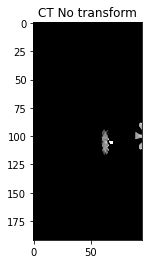

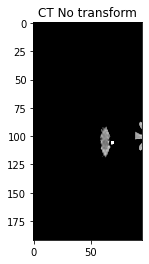

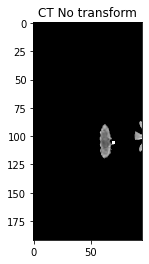

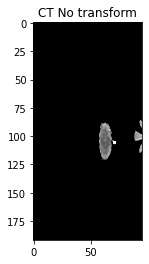

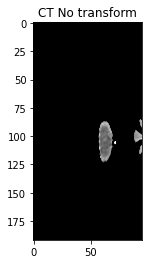

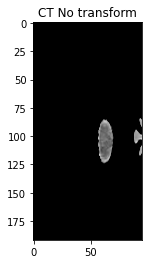

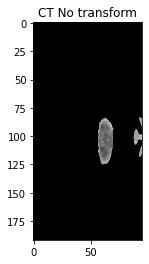

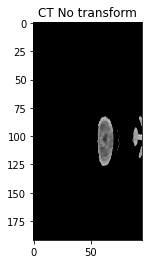

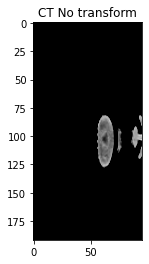

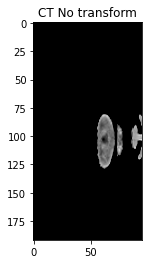

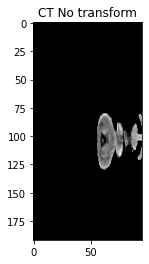

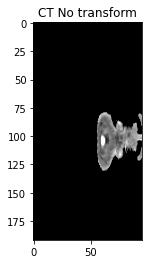

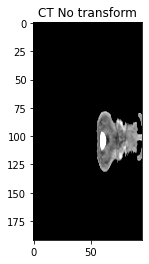

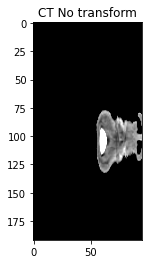

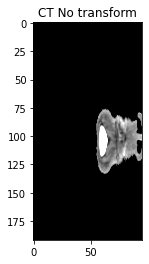

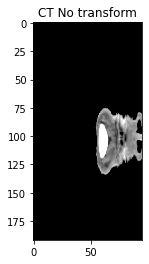

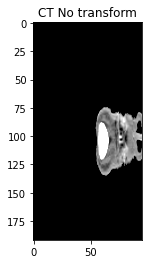

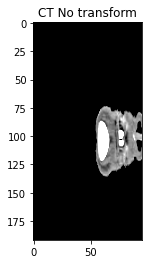

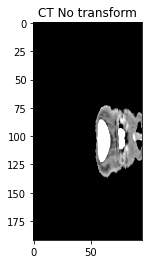

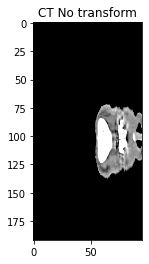

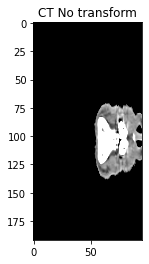

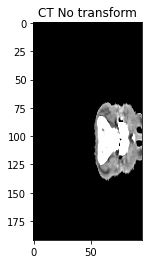

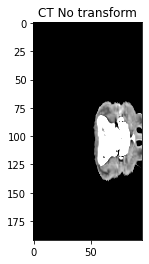

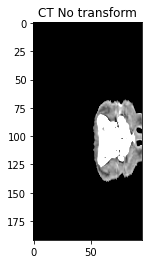

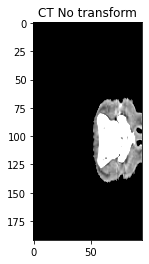

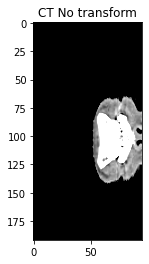

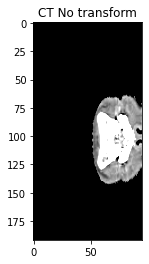

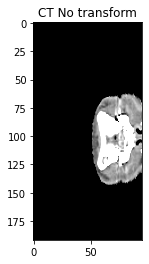

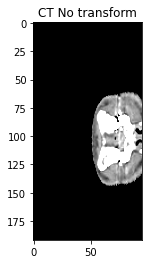

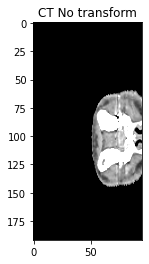

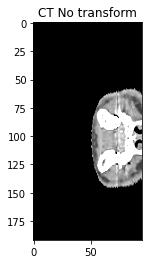

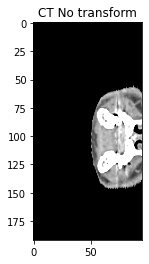

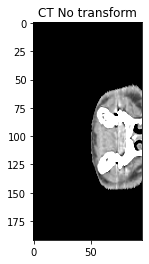

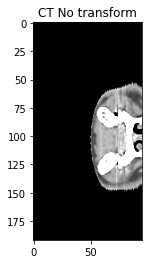

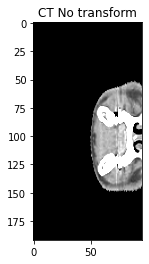

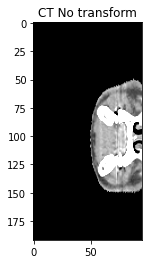

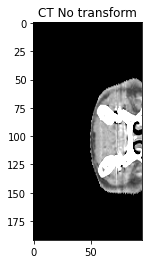

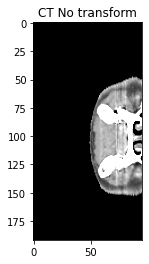

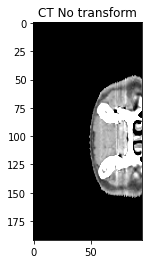

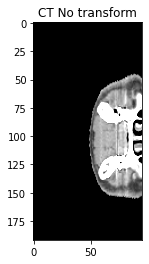

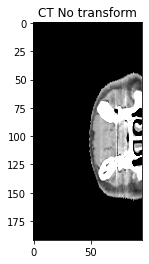

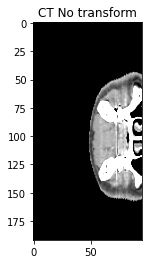

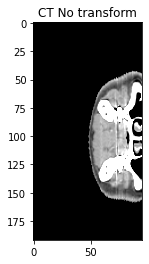

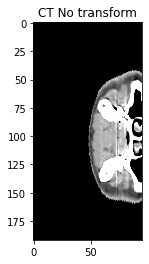

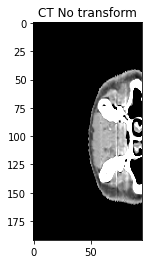

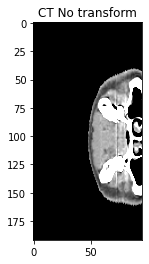

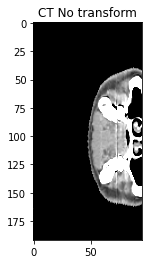

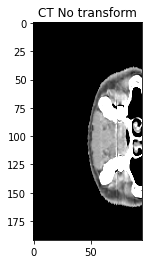

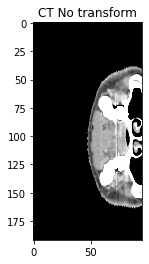

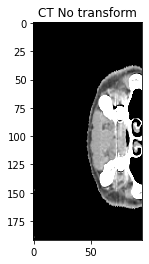

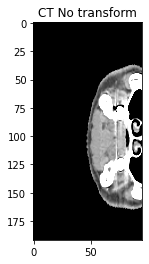

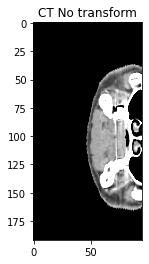

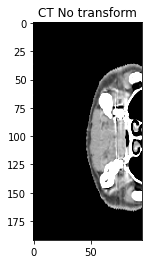

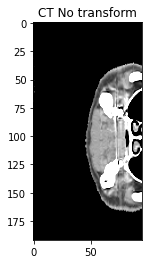

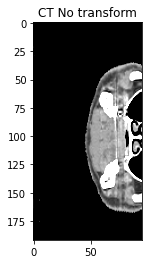

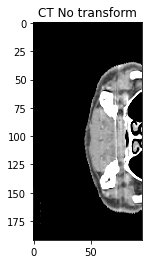

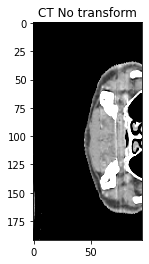

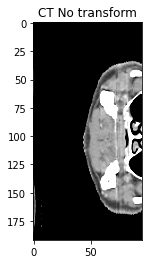

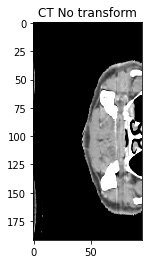

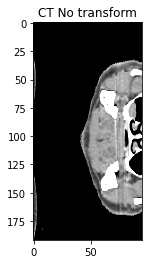

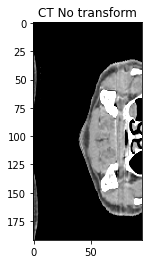

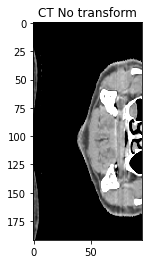

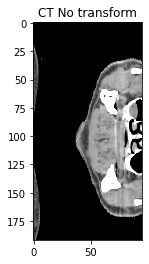

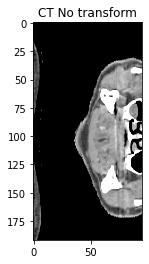

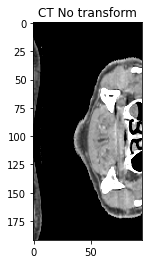

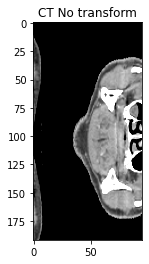

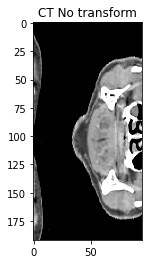

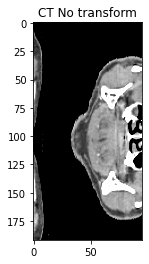

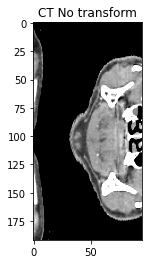

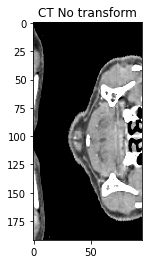

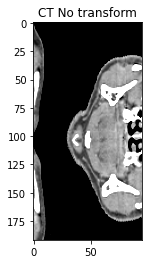

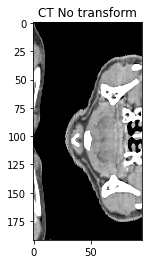

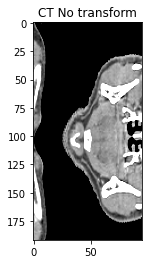

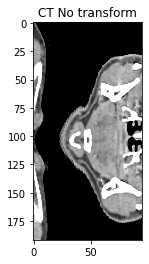

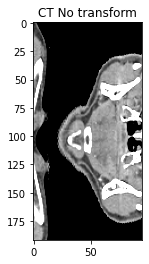

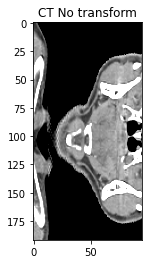

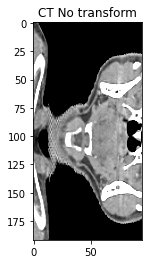

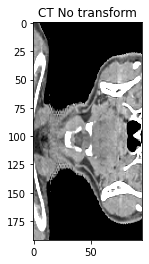

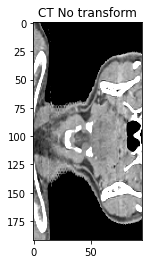

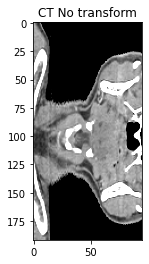

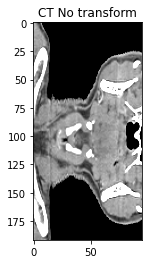

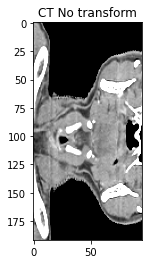

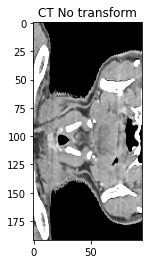

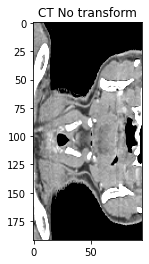

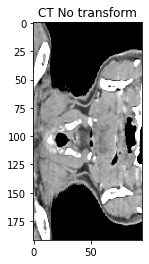

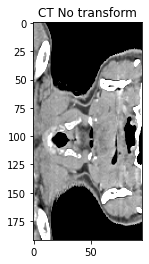

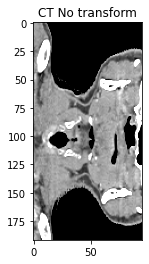

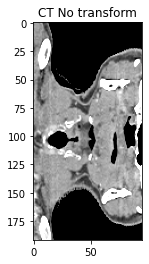

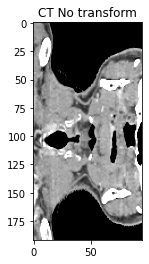

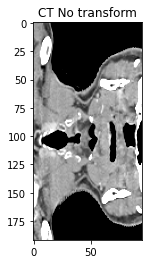

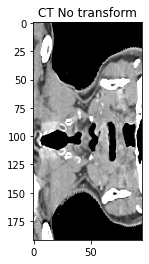

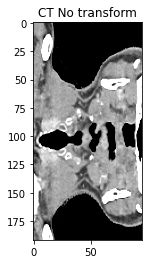

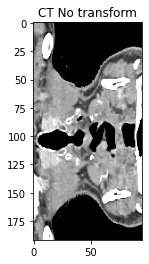

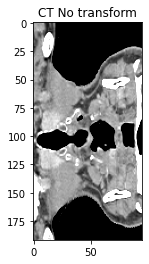

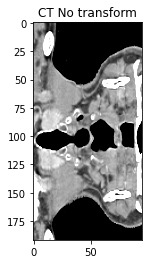

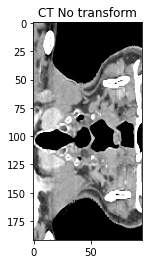

In [105]:
for i in range(0,ct_no_transf.shape[2]):
    plt.imshow(ct_no_transf[:,i,:], cmap='gray',vmin=-200,vmax=200)
    plt.title('CT No transform')
    plt.show()

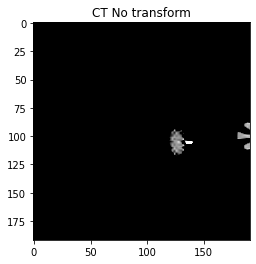

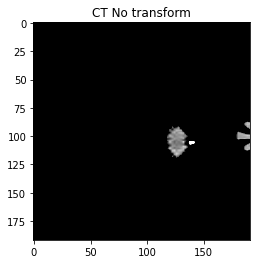

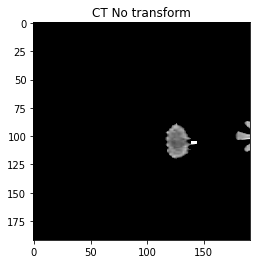

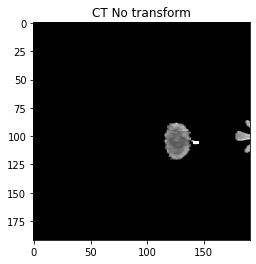

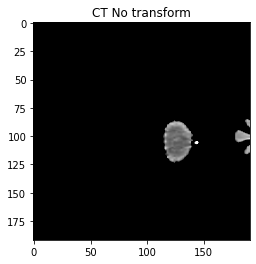

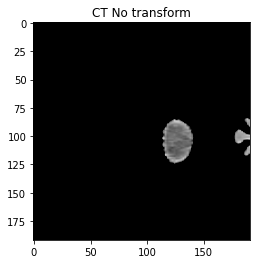

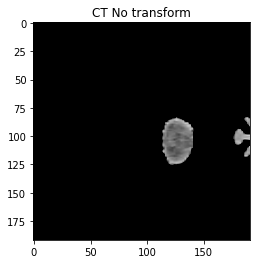

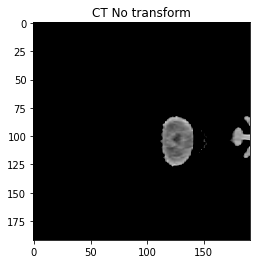

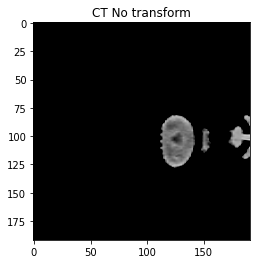

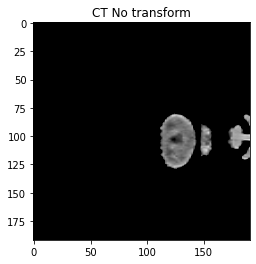

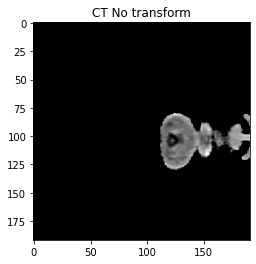

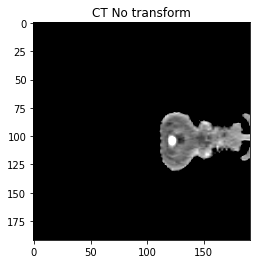

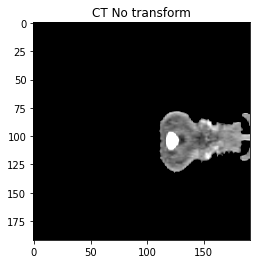

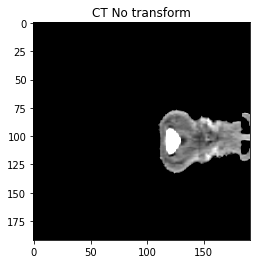

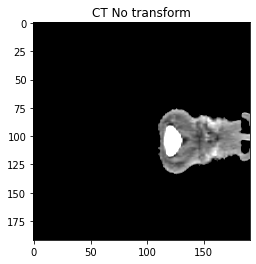

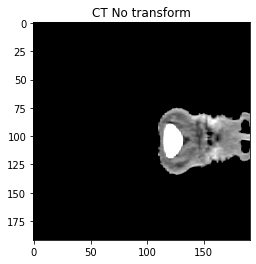

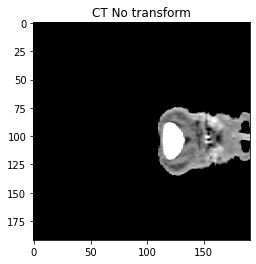

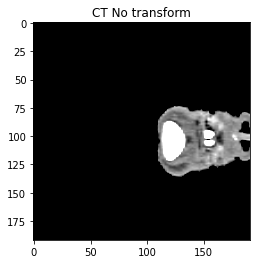

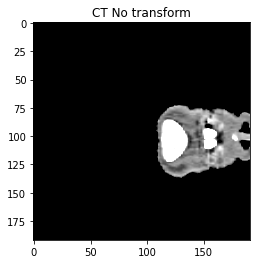

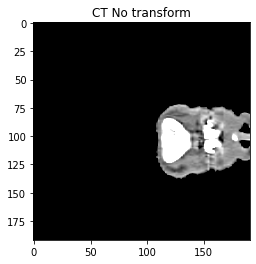

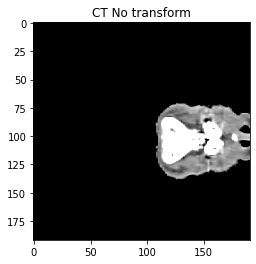

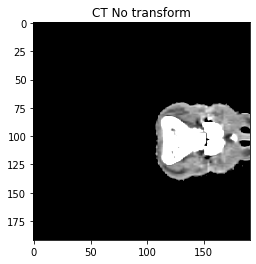

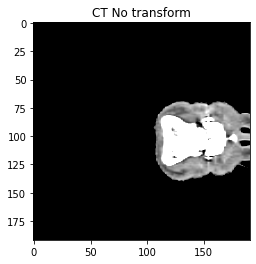

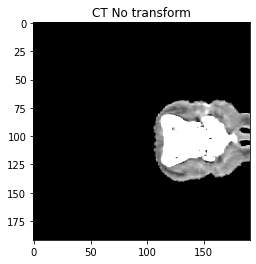

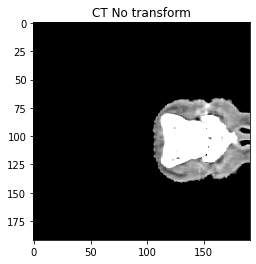

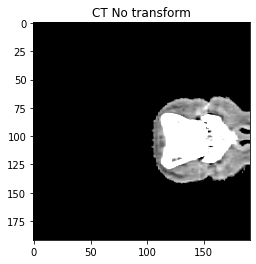

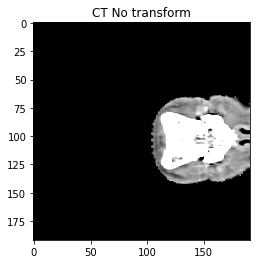

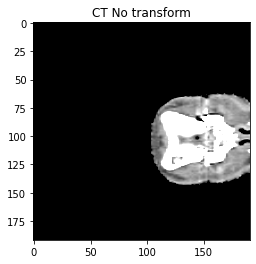

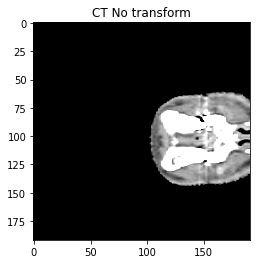

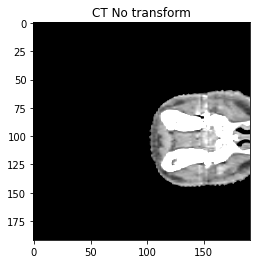

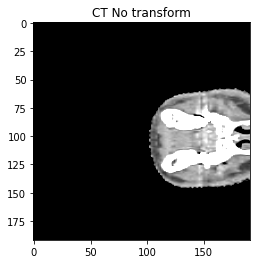

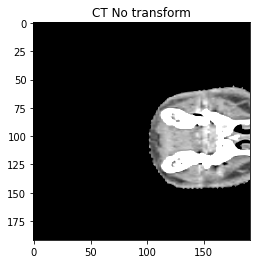

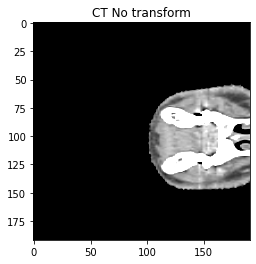

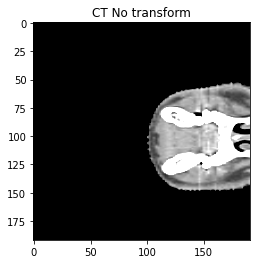

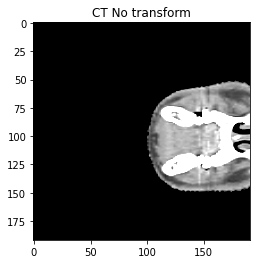

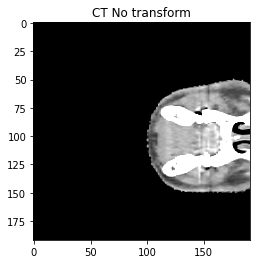

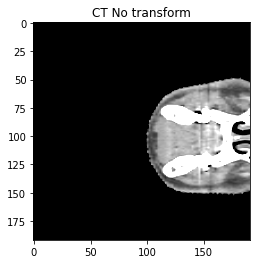

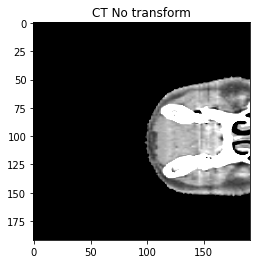

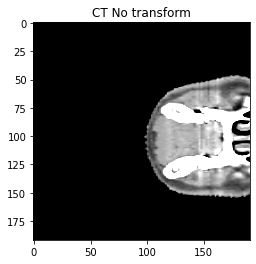

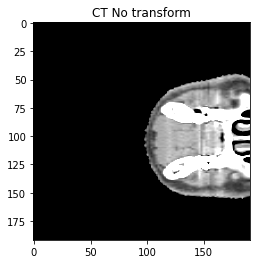

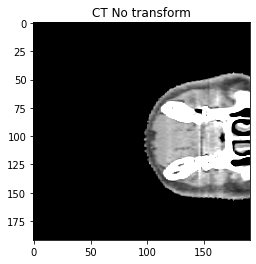

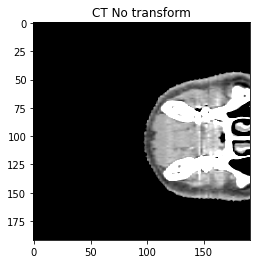

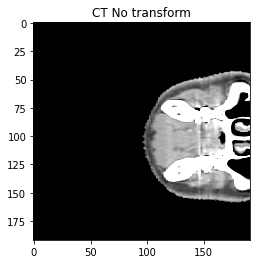

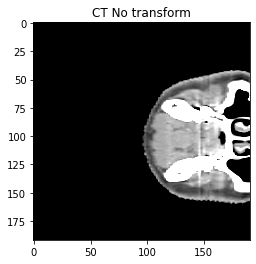

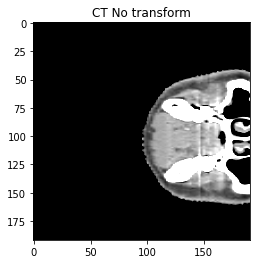

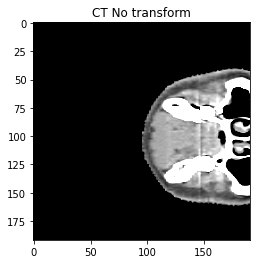

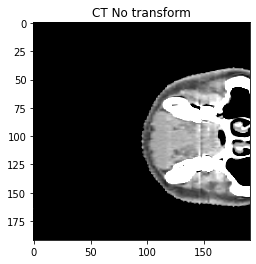

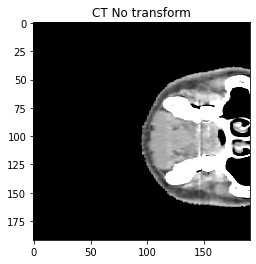

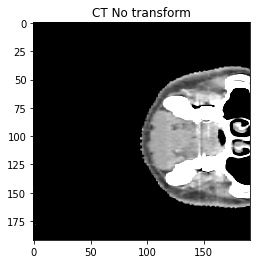

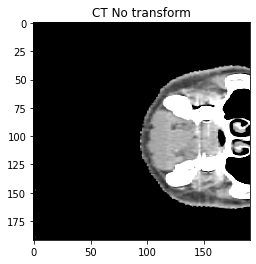

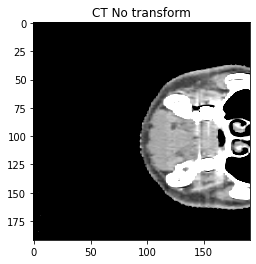

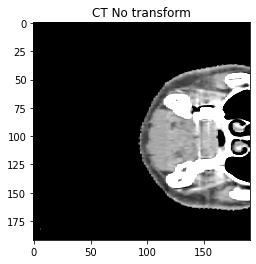

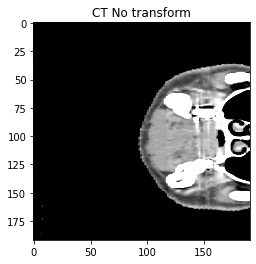

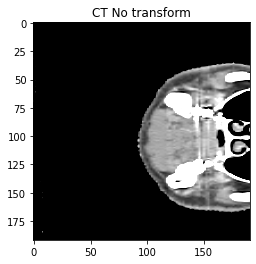

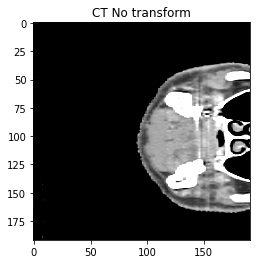

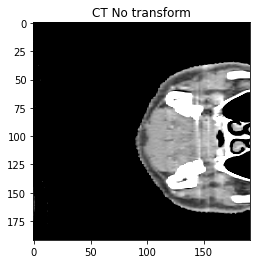

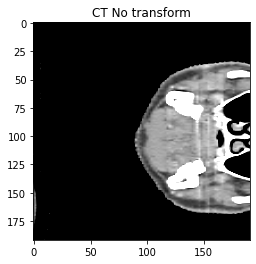

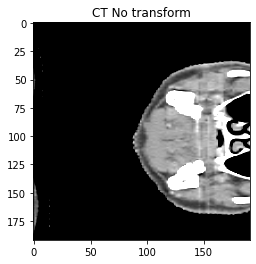

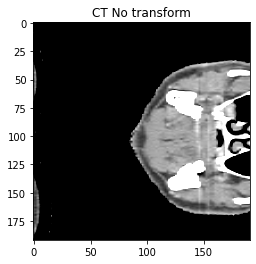

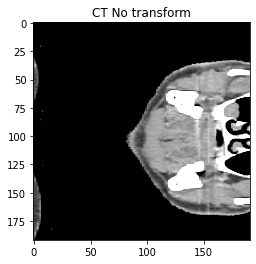

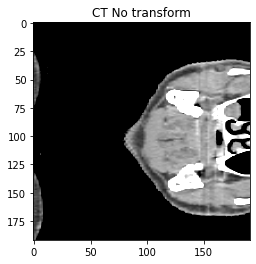

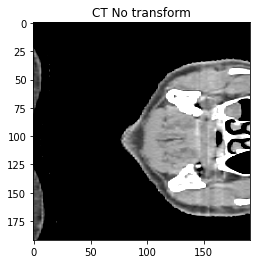

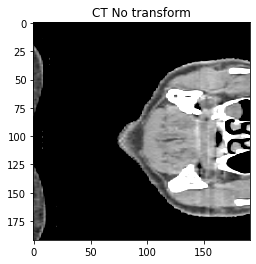

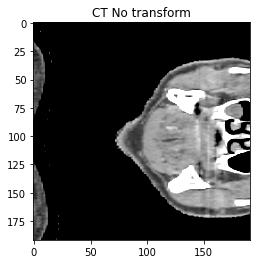

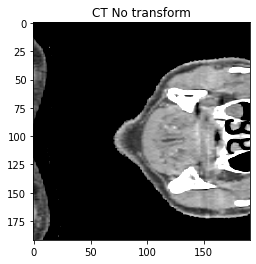

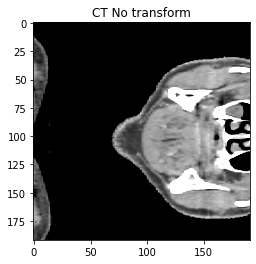

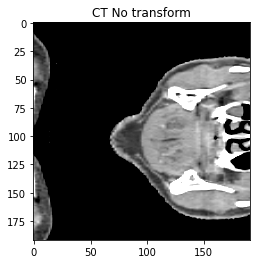

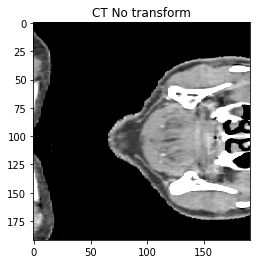

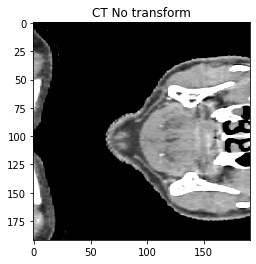

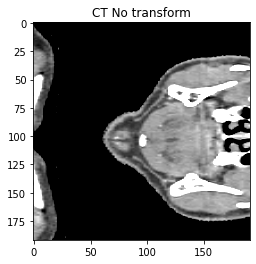

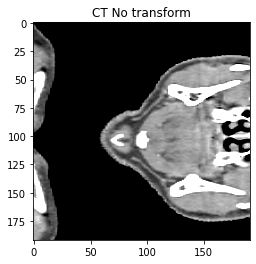

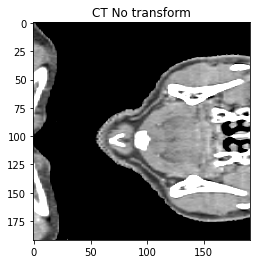

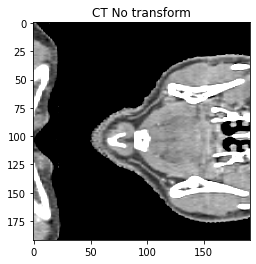

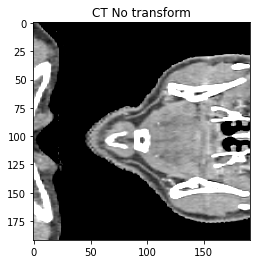

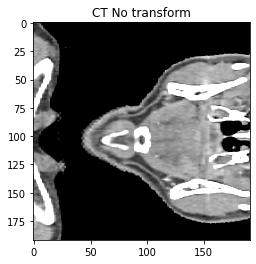

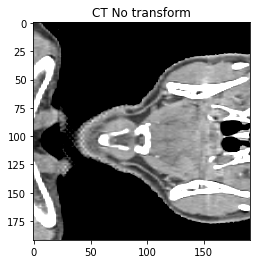

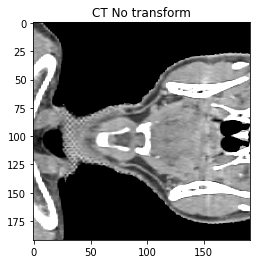

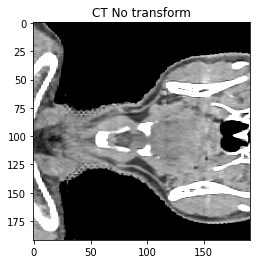

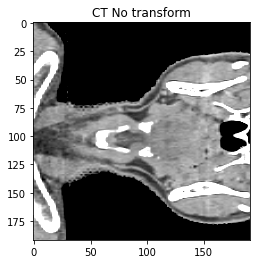

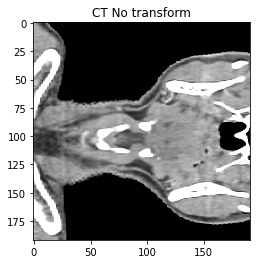

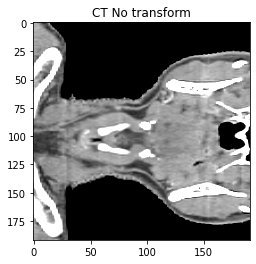

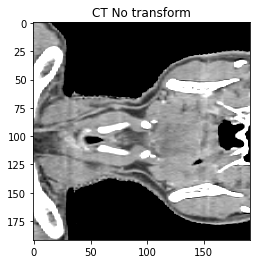

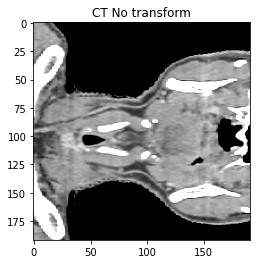

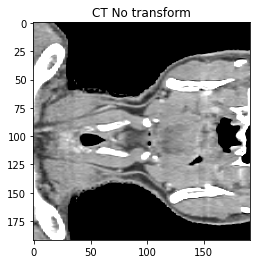

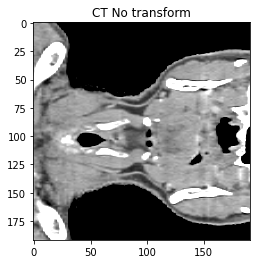

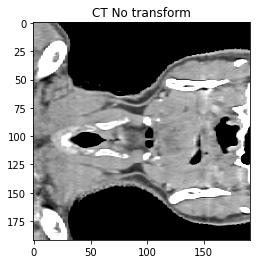

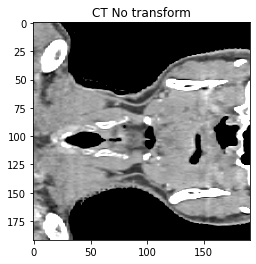

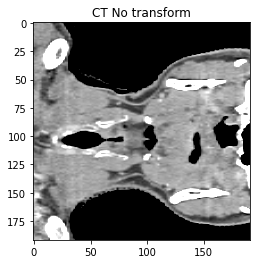

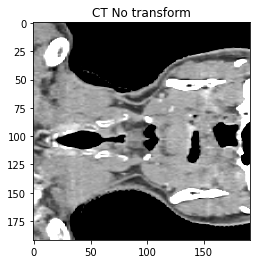

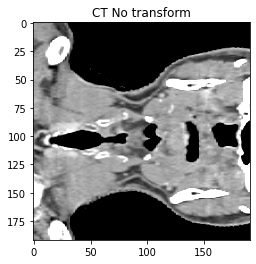

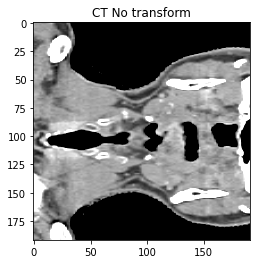

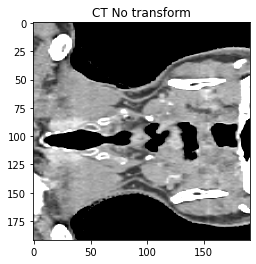

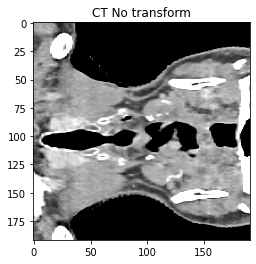

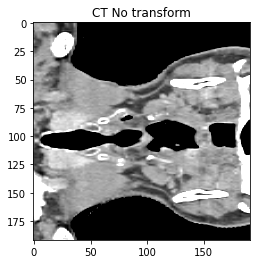

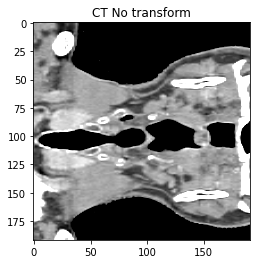

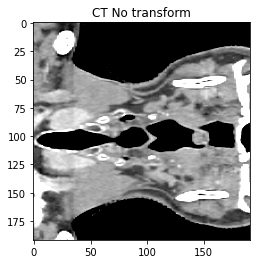

In [107]:
for i in range(0,ct_no_transf.shape[2]):
    plt.imshow(ct_transf[:,i,:], cmap='gray',vmin=-200,vmax=200)
    plt.title('CT No transform')
    plt.show()

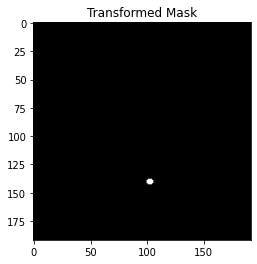

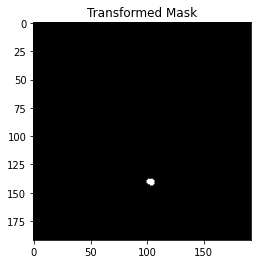

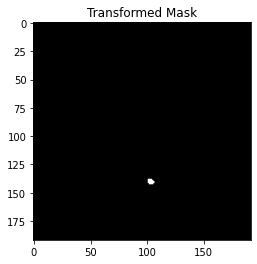

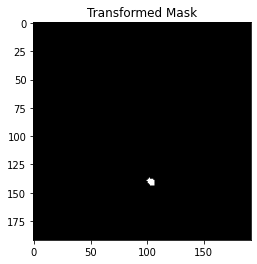

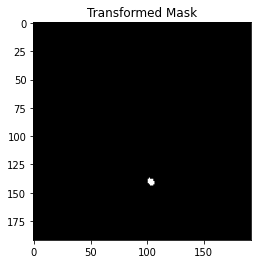

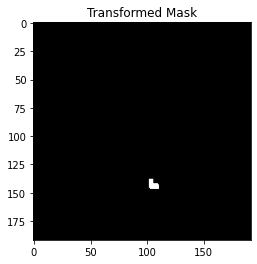

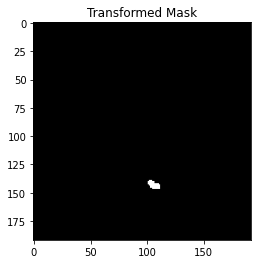

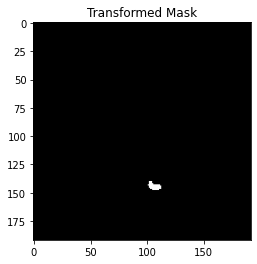

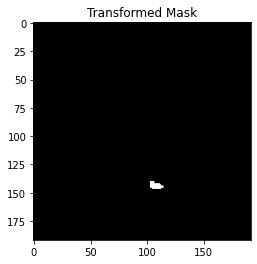

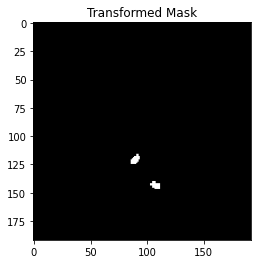

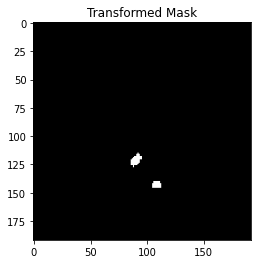

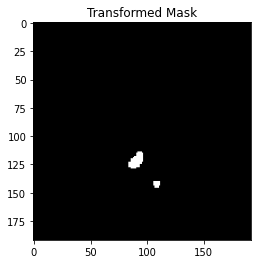

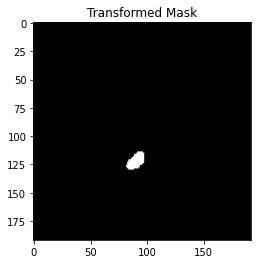

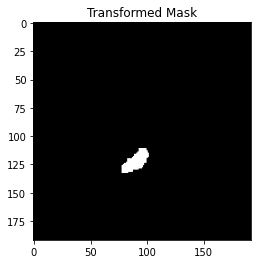

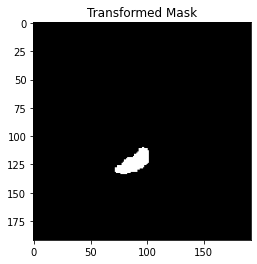

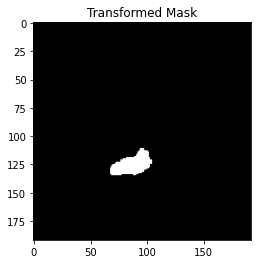

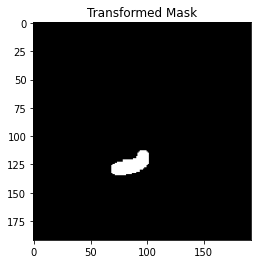

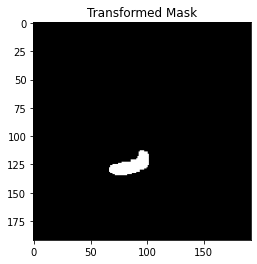

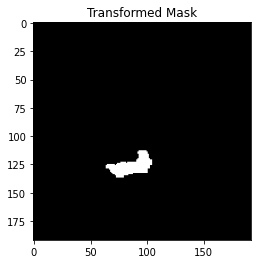

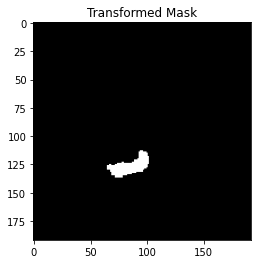

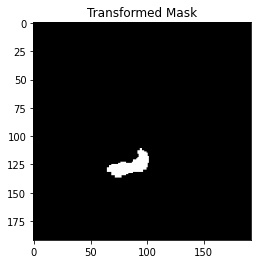

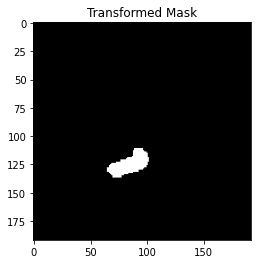

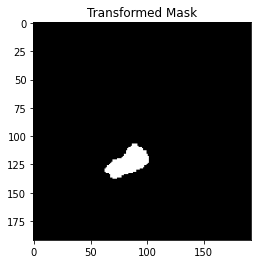

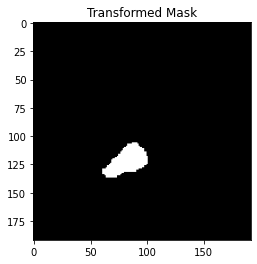

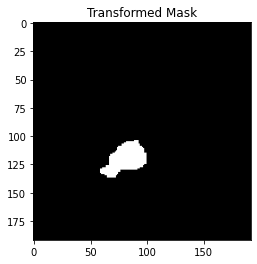

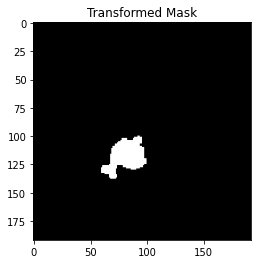

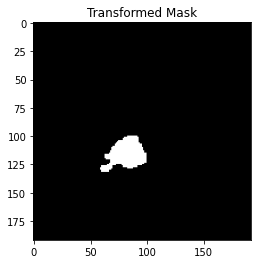

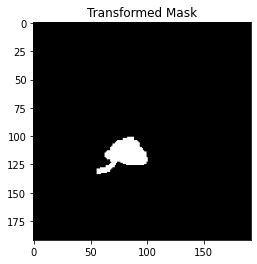

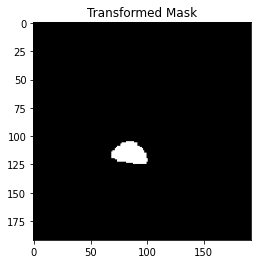

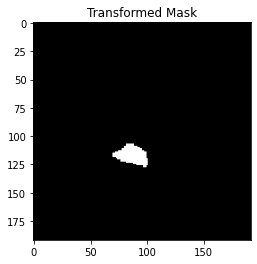

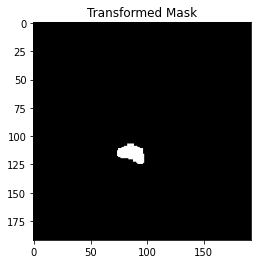

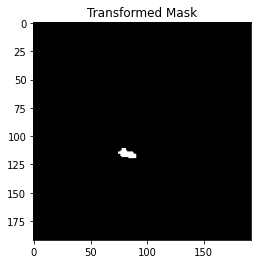

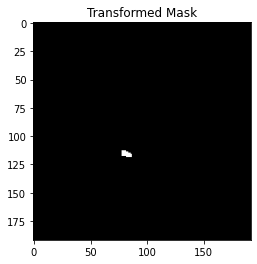

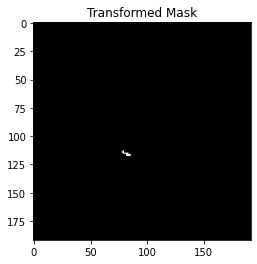

In [94]:
transforms = Compose([
    LoadImaged(keys=["mask"]),
    #Dilation(keys=["mask"], kernel_size=3),  # Apply your Dilate transform
])

# Apply the transform to your data
transformed_data = transforms(train_list)

# Visualize the transformed mask
mask = transformed_data[0]["mask"].squeeze()

for i in range(0,mask.shape[2]):
    if np.sum(mask[:,:,i])>0:
        plt.imshow(mask[:,:,i], cmap='gray')
        plt.title('Transformed Mask')
        plt.show()

### Check fraction numbers:

In [40]:
nums = list()

In [49]:
import os
import glob
path_to_data = "/scratch/hb-weeklyCT/dataLongitudinal/"
split_file = os.path.join("/scratch/hb-weeklyCT/experimentsLongitudinal/data_split/data_split_seqNum_2.txt")
split_data = read_split_file(split_file)

In [51]:
test_ids = split_data['test']
train_ids = split_data['train']

In [52]:
all_patients = test_ids+train_ids

In [53]:
#nums = list()
for id_ in train_ids:
    fr_cts = glob.glob(os.path.join(path_to_data,id_,"*fr*reg*"))
    fr_cts_num = [int(l.split("_")[3]) for l in fr_cts]
    
    fr_cts_num.sort()
    nums = nums + [id_ + ' | ' + str(i) for i in fr_cts_num[:2]]

In [54]:
pd.DataFrame(list(set(nums))).to_excel("/scratch/hb-weeklyCT/experimentsLongitudinal/data_split/fractions_id.xlsx")

In [48]:
nums = list()
results = list()

for id_ in train_ids:
    fr_cts = glob.glob(os.path.join(path_to_data,id_,"*fr*reg*"))
    fr_cts_num = [int(l.split("_")[3]) for l in fr_cts]
    #print(id_)
    fr_cts_num.sort()
    nums.append(fr_cts_num)
    
    diff1 = fr_cts_num[1] - fr_cts_num[0]
    diff2 = fr_cts_num[2] - fr_cts_num[1]
    diff3 = fr_cts_num[3] - fr_cts_num[2]
    
    results.append((diff1, diff2, diff3))

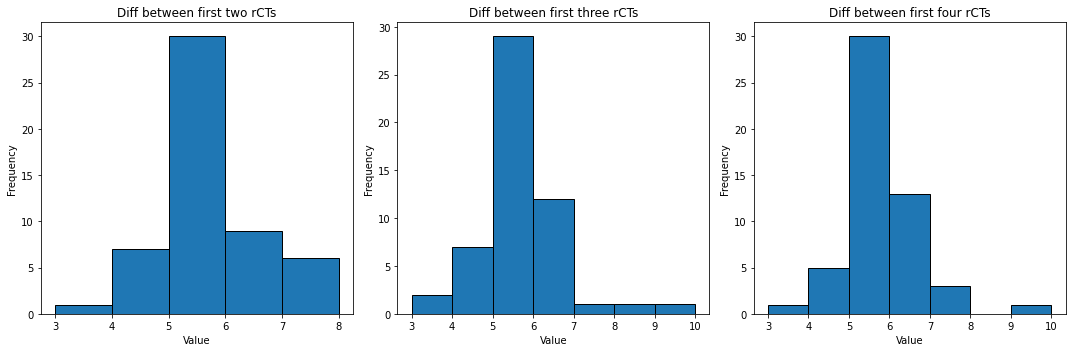

In [24]:
first_elements = [t[0] for t in results]
second_elements = [t[1] for t in results]
third_elements = [t[2] for t in results]

# Plot histograms
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.hist(first_elements, bins=range(min(first_elements), max(first_elements) + 2), edgecolor='black')
plt.title('Diff between first two rCTs')
plt.xlabel('Value')
plt.ylabel('Frequency')

plt.subplot(1, 3, 2)
plt.hist(second_elements, bins=range(min(second_elements), max(second_elements) + 2), edgecolor='black')
plt.title('Diff between first three rCTs')
plt.xlabel('Value')
plt.ylabel('Frequency')

plt.subplot(1, 3, 3)
plt.hist(third_elements, bins=range(min(third_elements), max(third_elements) + 2), edgecolor='black')
plt.title('Diff between first four rCTs')
plt.xlabel('Value')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

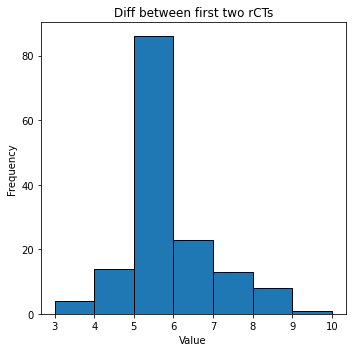

In [32]:
first_elements = [t[0] for t in results]
second_elements = [t[1] for t in results]
third_elements = [t[2] for t in results]

# Plot histograms
plt.figure(figsize=(5, 5))

plt.subplot(1, 1, 1)
plt.hist(first_elements, bins=range(min(first_elements), max(first_elements) + 2), edgecolor='black')
plt.title('Diff between first two rCTs')
plt.xlabel('Value')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

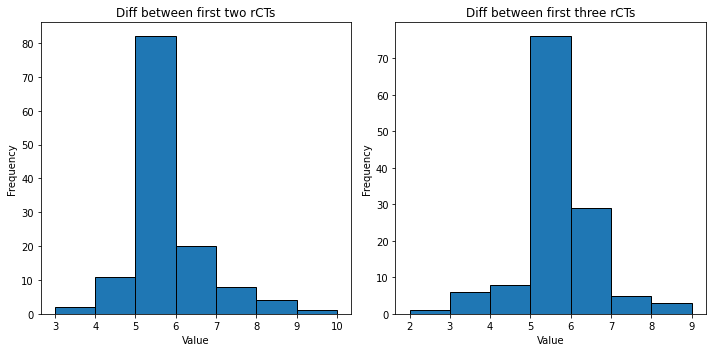

In [45]:
first_elements = [t[0] for t in results]
second_elements = [t[1] for t in results]
third_elements = [t[2] for t in results]

# Plot histograms
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.hist(first_elements, bins=range(min(first_elements), max(first_elements) + 2), edgecolor='black')
plt.title('Diff between first two rCTs')
plt.xlabel('Value')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.hist(second_elements, bins=range(min(second_elements), max(second_elements) + 2), edgecolor='black')
plt.title('Diff between first three rCTs')
plt.xlabel('Value')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

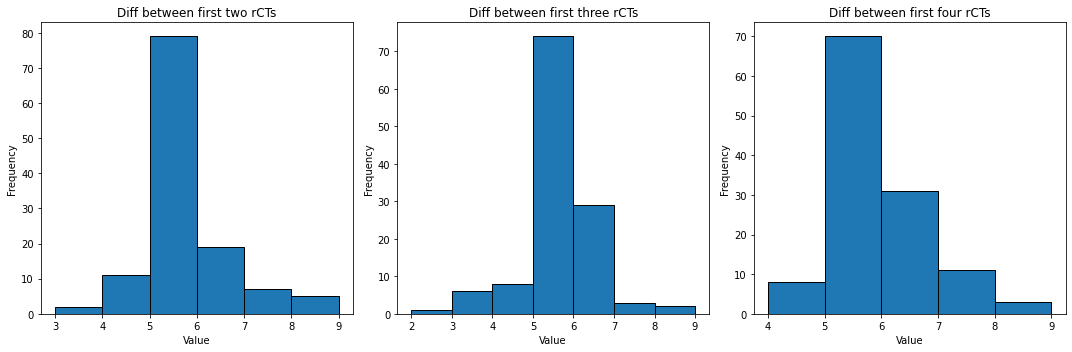

In [49]:
first_elements = [t[0] for t in results]
second_elements = [t[1] for t in results]
third_elements = [t[2] for t in results]

# Plot histograms
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.hist(first_elements, bins=range(min(first_elements), max(first_elements) + 2), edgecolor='black')
plt.title('Diff between first two rCTs')
plt.xlabel('Value')
plt.ylabel('Frequency')

plt.subplot(1, 3, 2)
plt.hist(second_elements, bins=range(min(second_elements), max(second_elements) + 2), edgecolor='black')
plt.title('Diff between first three rCTs')
plt.xlabel('Value')
plt.ylabel('Frequency')

plt.subplot(1, 3, 3)
plt.hist(third_elements, bins=range(min(third_elements), max(third_elements) + 2), edgecolor='black')
plt.title('Diff between first four rCTs')
plt.xlabel('Value')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()